# Figure Demo

This notebook uses a forward genetic query that produces three figure types with visibly separated evidence matches: an evidence-match map, a clustered function-by-match heatmap, and a functional-program support plot.

In [1]:
from pathlib import Path
import os
import sys
import warnings
from IPython.display import display

warnings.filterwarnings("ignore", message="IProgress not found.*")

repo_root = Path.cwd()
if not (repo_root / "src" / "pxfquery").exists() and (repo_root.parent / "src" / "pxfquery").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / "src"))

# Optional: load local environment variables for the LLM provider.
for env_file in [Path.cwd() / ".env", Path.cwd().parent / ".env", Path.home() / ".env"]:
    if env_file.exists():
        for line in env_file.read_text(encoding="utf-8").splitlines():
            line = line.strip()
            if line and not line.startswith("#") and "=" in line:
                key, value = line.split("=", 1)
                os.environ.setdefault(key.strip(), value.strip())

from pxfquery import PxFQuery

pxf = PxFQuery()
print("PxFquery", pxf.version)
resource_status = pxf.resources.status()
resource_info = resource_status.to_dict() if hasattr(resource_status, "to_dict") else dict(resource_status)
print("Resource status:")
print({
    "available": resource_info.get("available"),
    "source": resource_info.get("source"),
    "version": resource_info.get("version"),
    "available_file_count": len(resource_info.get("available_files") or {}),
})

PxFquery 0.5.12.dev0
Resource status:
{'available': True, 'source': 'manifest', 'version': 'v20260628', 'available_file_count': 18}


In [2]:
from pathlib import Path
from IPython.display import Image, display

out_dir = Path("pxfquery_demo_figures")
out_dir.mkdir(exist_ok=True)

question = "In lung cancer models, what functional programs are changed after TP53 knockdown?"

print("Question:")
print(question)

qdata = pxf.tl.parse(question, top_n=8)
pxf.tl.answer(qdata)
answer = pxf.get.answer(qdata)

print("\nAnswer preview:")
print(answer.summary[:700])

print("\nFigure specifications:")
for index, spec in enumerate(answer.figures, 1):
    points = len(spec.get("points", [])) if spec.get("kind") == "evidence_match_map" else ""
    print(f"{index}. {spec.get('title')} | {spec.get('kind')} | points={points}")

Question:
In lung cancer models, what functional programs are changed after TP53 knockdown?


[Parsing] start


[Parsing] done | mode=forward; context=lung cancer models; perturbation=TP53; time=1.58s
[Matching] start


[Matching] done | matches=6; time=4.81s
[Matrix] start


[Matrix] done | profiles=6; skipped=0; time=0.39s
[Evidence] start


[Evidence] done | status=ready; time=6.34s



Answer preview:
In lung cancer models, TP53 knockdown is associated with increased MYC targets, unfolded protein response, and TNFα signaling via NF-κB, and decreased epithelial-mesenchymal transition (EMT), protein maturation, and platelet activation in A549 cells. In HCC515 cells, it increases respiration, translation initiation, oxidative phosphorylation, MYC targets, and interferon alpha response, while decreasing cell cycle (G1/S and G2/M), E2F targets, and NPC/OPC programs. The evidence is mixed across cell lines: A549 shows suppression of EMT programs, whereas HCC515 shows suppression of cell cycle programs.

Figure specifications:
1. Evidence Match Map | evidence_match_map | points=6
2. Functional Signal Clustered By Evidence Match | function_match_heatmap | points=
3. Functional Program Evidence Support | function_consensus_bar | points=


In [3]:
pxf.tl.figures(qdata, output_dir=out_dir / "pdf", format="pdf")
print("PDF files:")
for path in qdata.uns["figure_outputs"]:
    print(path)

PDF files:
pxfquery_demo_figures/pdf/pxfquery_01_evidence_match_map.pdf
pxfquery_demo_figures/pdf/pxfquery_02_function_match_heatmap.pdf
pxfquery_demo_figures/pdf/pxfquery_03_function_consensus_bar.pdf


In [4]:
pxf.tl.figures(qdata, output_dir=out_dir / "png", format="png")
png_paths = [Path(path) for path in qdata.uns["figure_outputs"]]
print("PNG files:")
for path in png_paths:
    print(path)

PNG files:
pxfquery_demo_figures/png/pxfquery_01_evidence_match_map.png
pxfquery_demo_figures/png/pxfquery_02_function_match_heatmap.png
pxfquery_demo_figures/png/pxfquery_03_function_consensus_bar.png


## Figure 1: Evidence Match Map

Preview: pxfquery_demo_figures/png/pxfquery_01_evidence_match_map.png


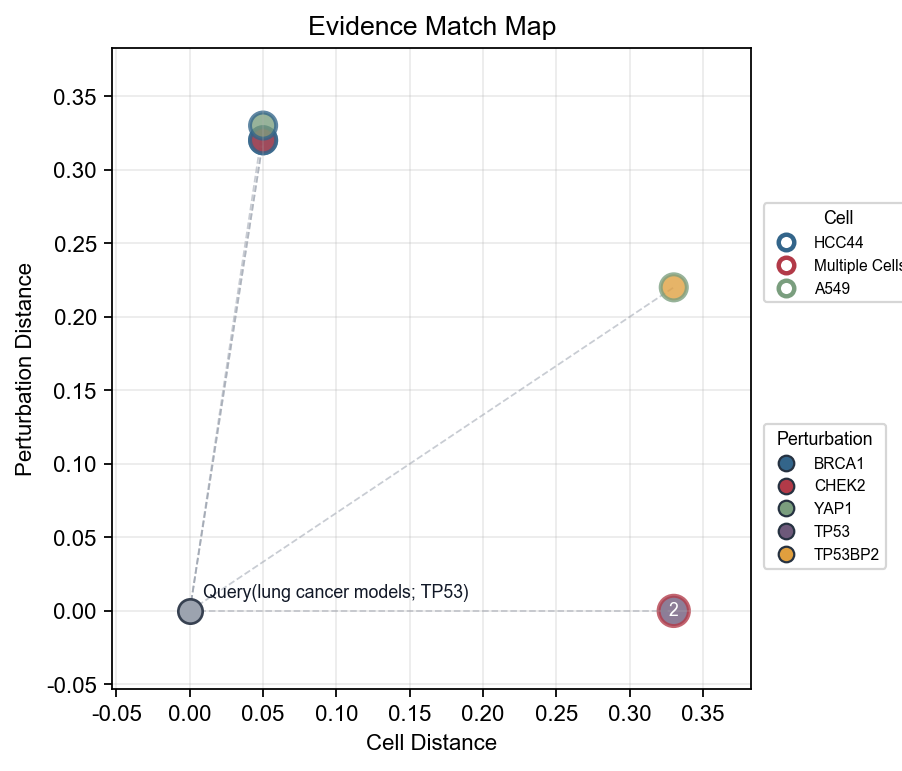

In [5]:
print("Preview:", png_paths[0])
display(Image(filename=str(png_paths[0])))

## Figure 2: Functional Signal Clustered By Evidence Match

Preview: pxfquery_demo_figures/png/pxfquery_02_function_match_heatmap.png


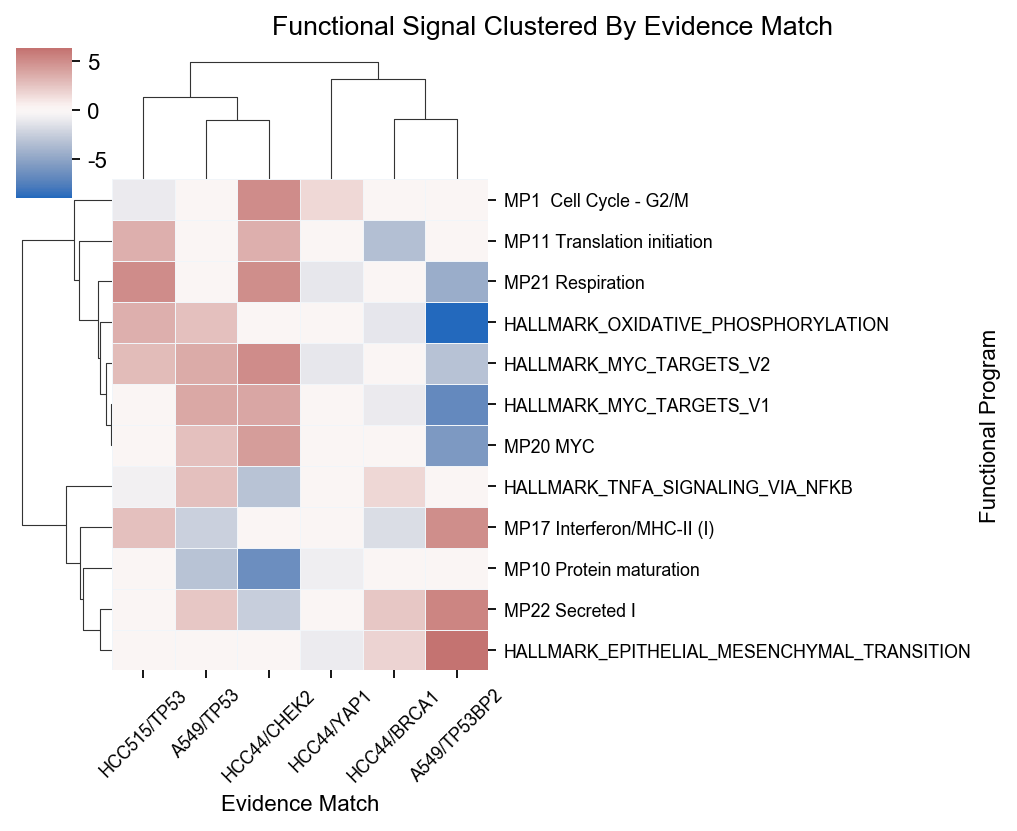

In [6]:
print("Preview:", png_paths[1])
display(Image(filename=str(png_paths[1])))

## Figure 3: Functional Program Evidence Support

Preview: pxfquery_demo_figures/png/pxfquery_03_function_consensus_bar.png


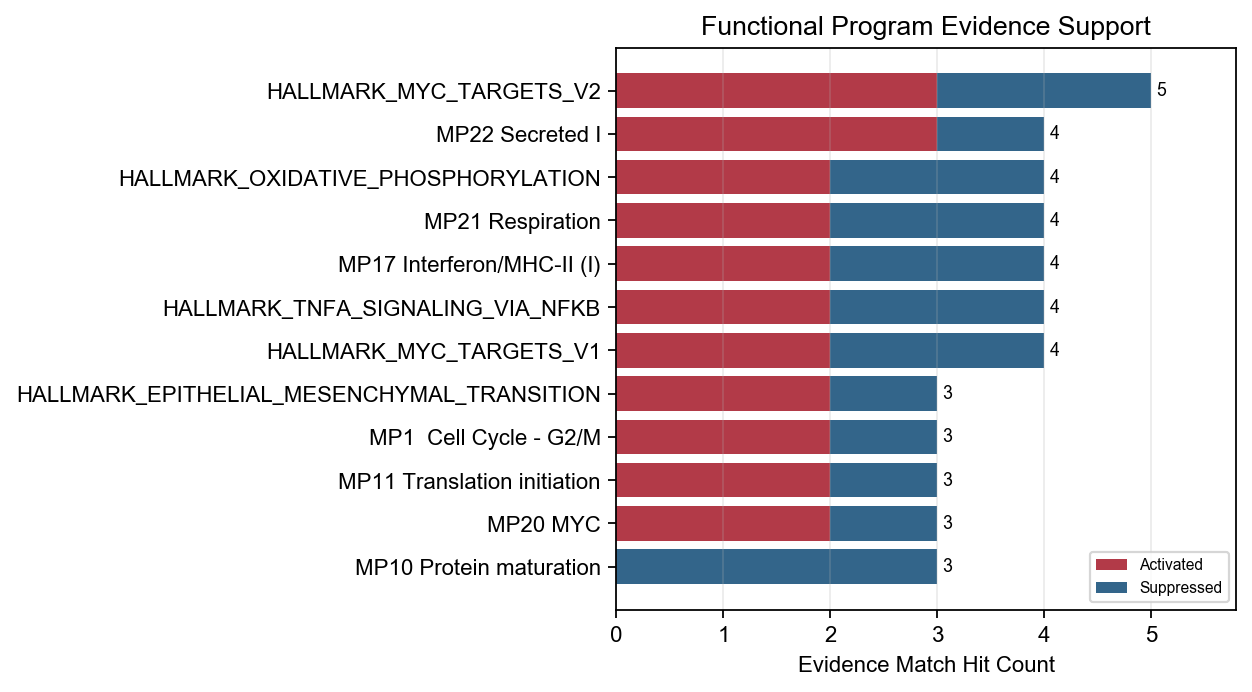

In [7]:
print("Preview:", png_paths[2])
display(Image(filename=str(png_paths[2])))